<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_Based_Heart_Attack_Prediction_System_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ).csv')
df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.head()

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.tail()

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.shape

(237630, 35)

In [ ]:
df.columns

Index(['tientID', 'State', 'Sex', 'GeneralHealth', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
tientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='HadHeartAttack'

In [ ]:
df[target].value_counts()

,count
HadHeartAttack,
0,224429
1,13201


In [ ]:
df[target].value_counts()

,count
HadHeartAttack,
0,224429
1,13201


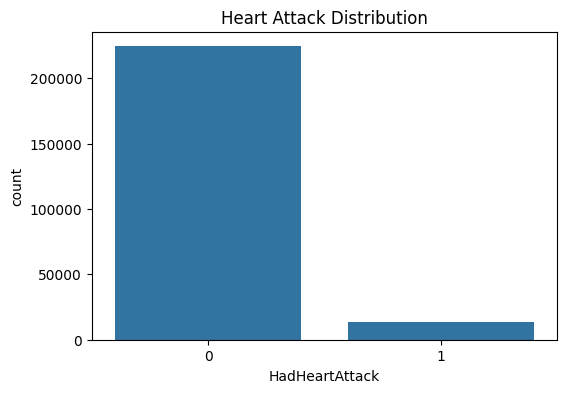

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Heart Attack Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['State', 'Sex', 'GeneralHealth', 'AgeCategory', 'HadDiabetes',
       'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory',
       'TetanusLast10Tdap'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['tientID', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'ChestScan',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos'],
      dtype='object')

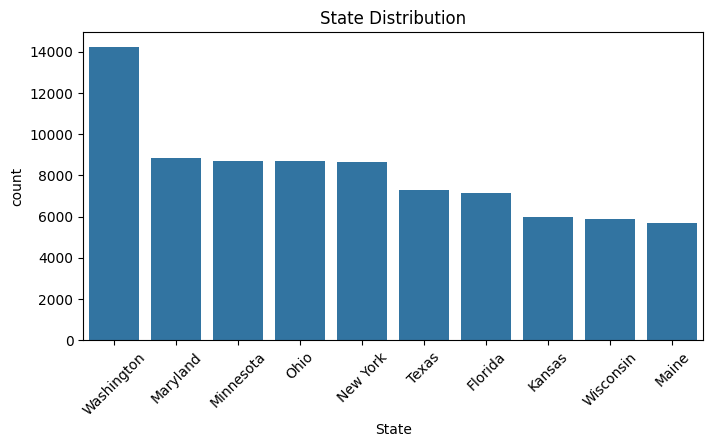

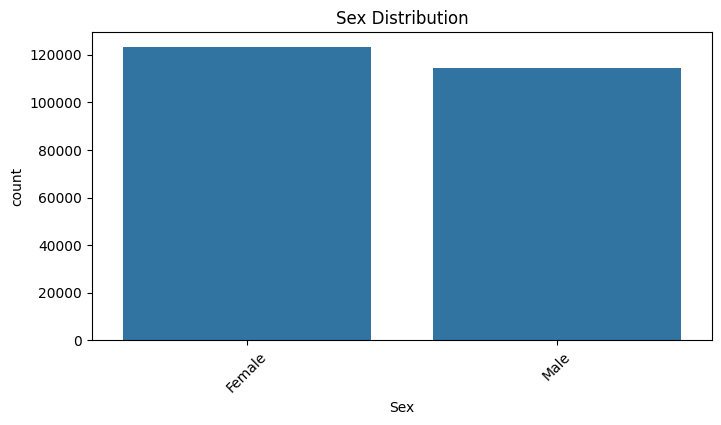

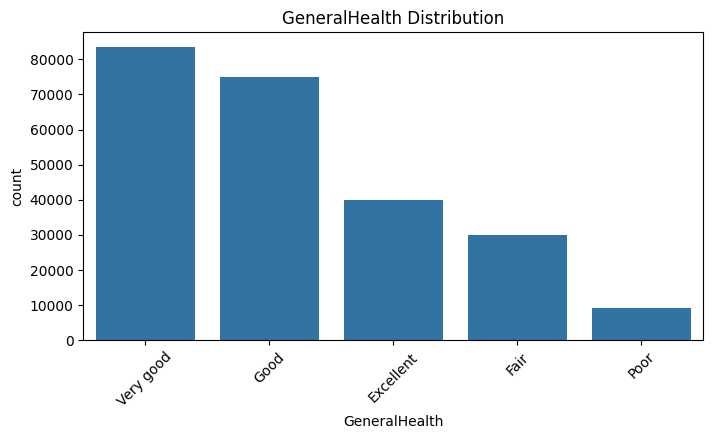

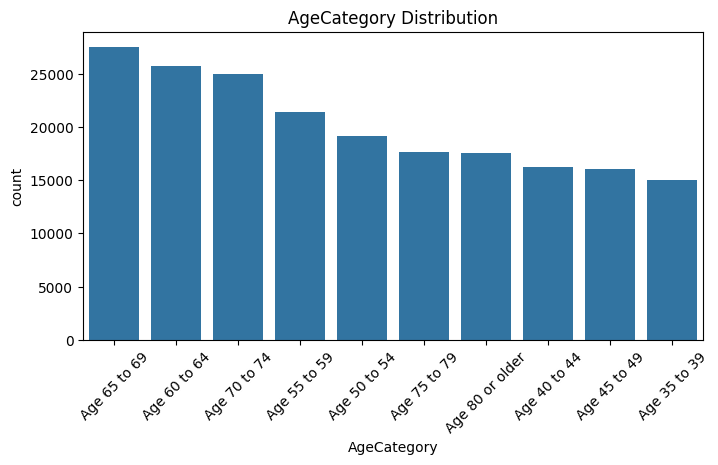

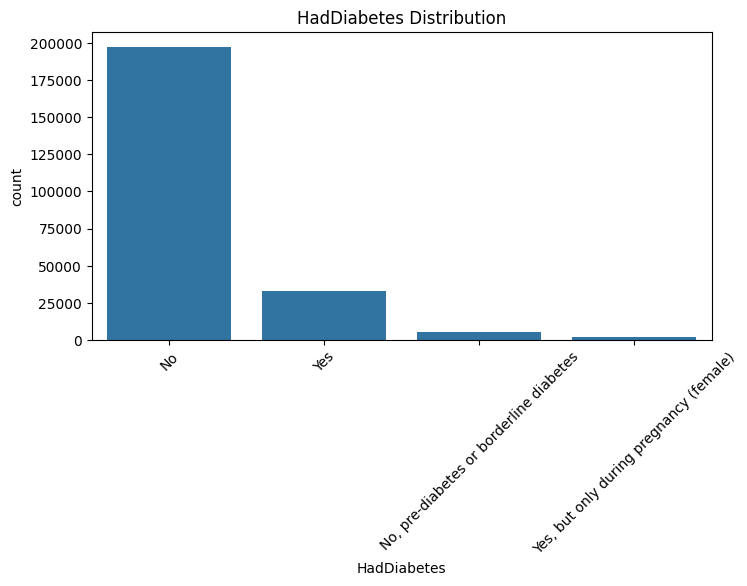

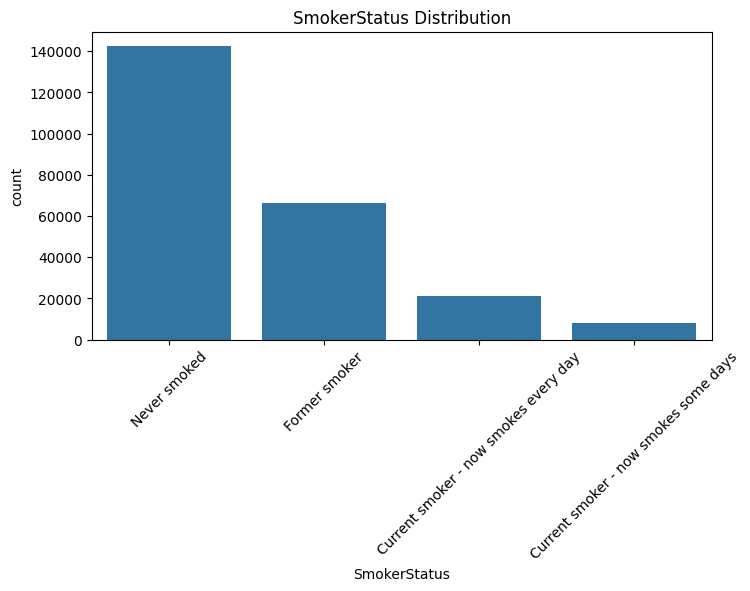

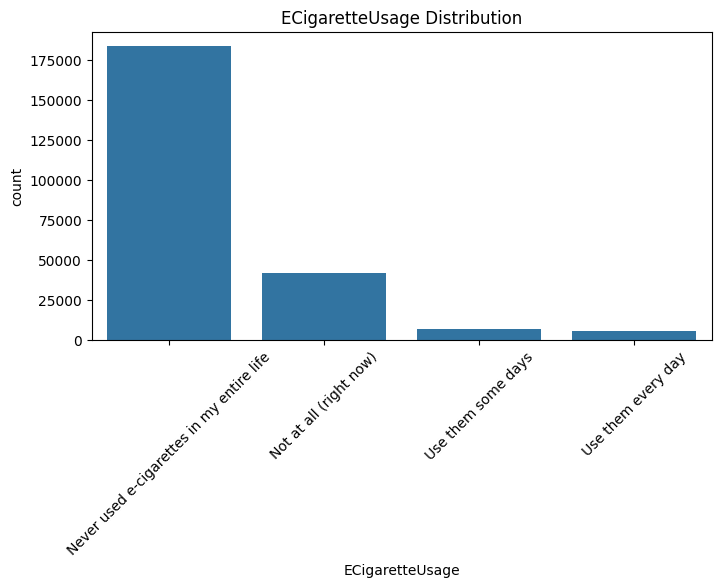

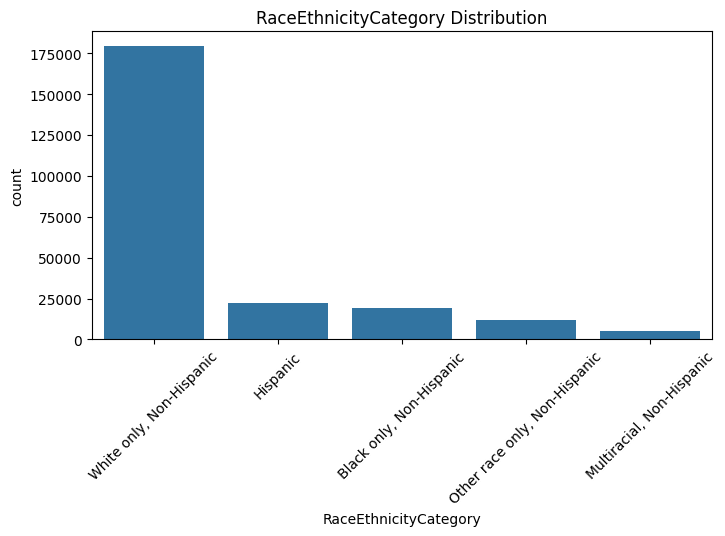

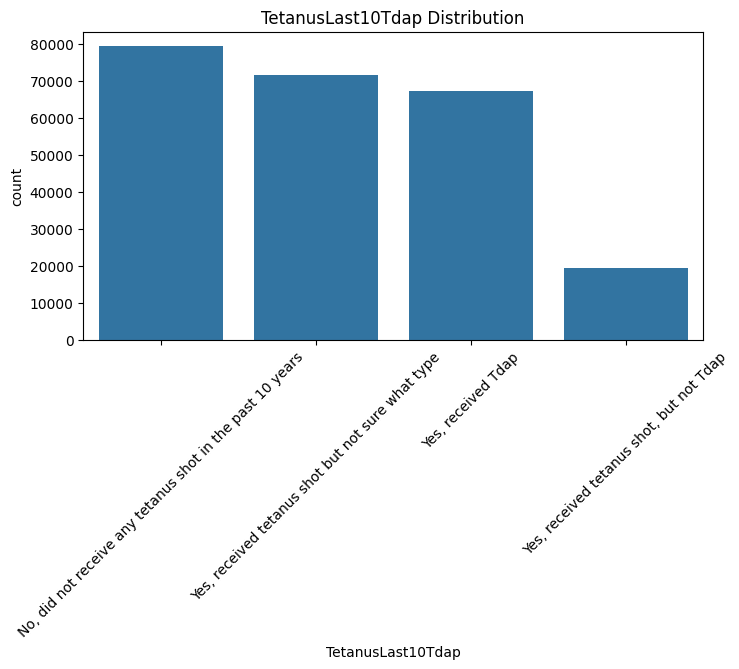

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution')
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


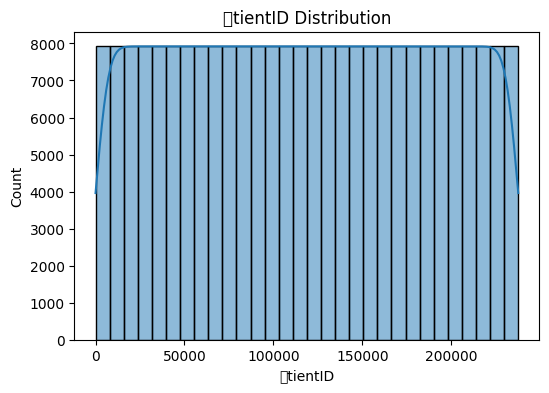

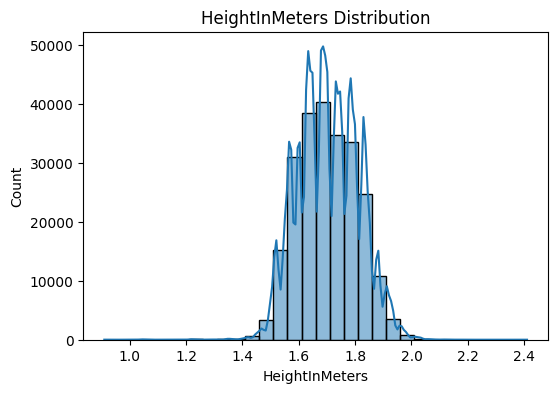

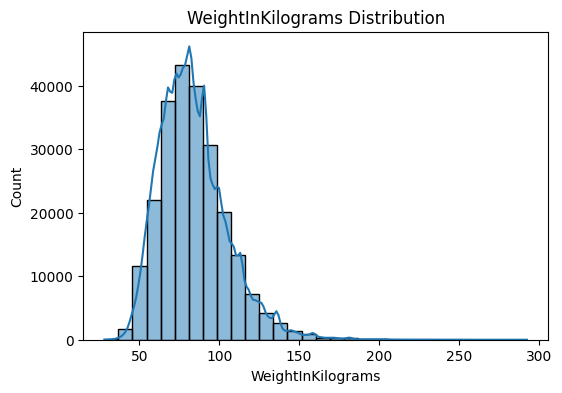

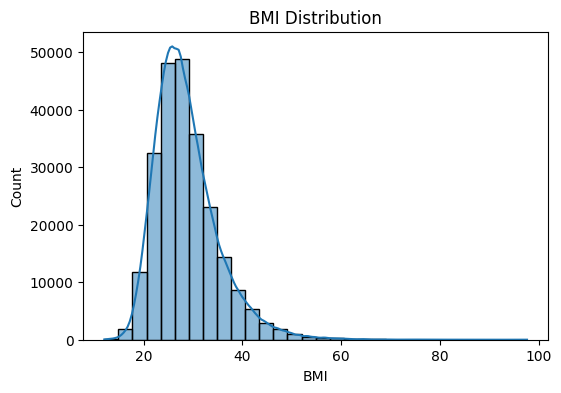

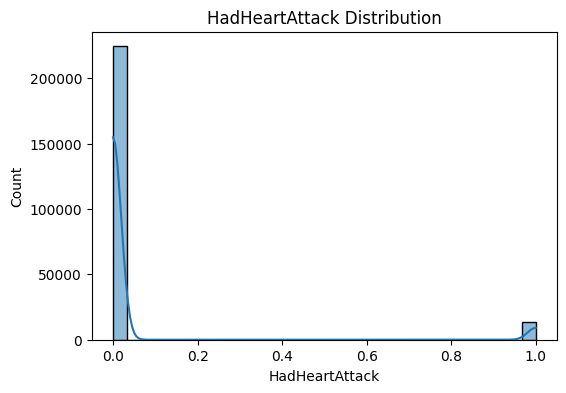

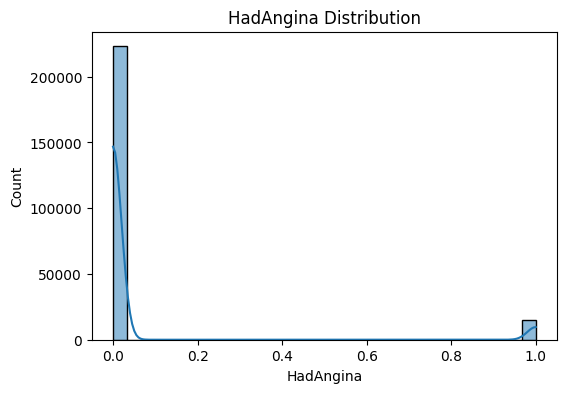

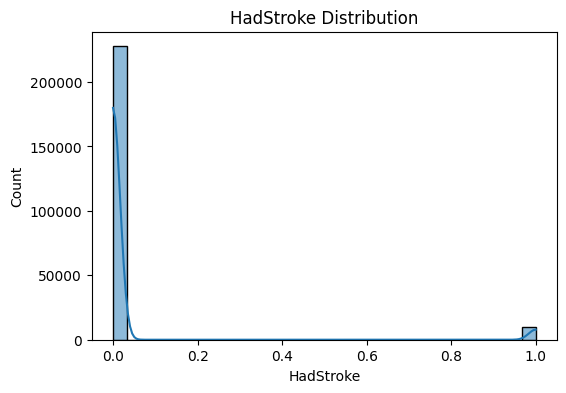

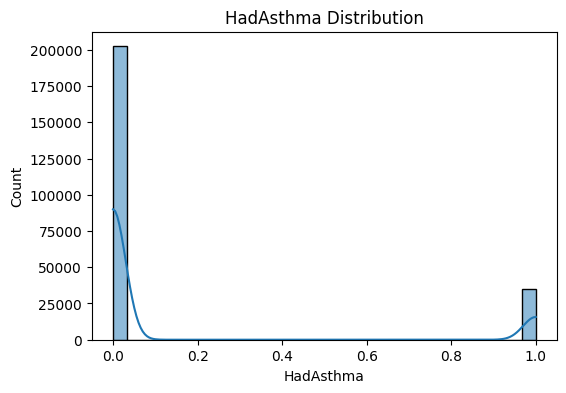

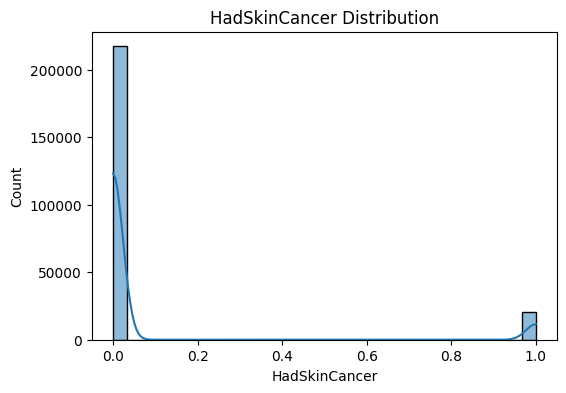

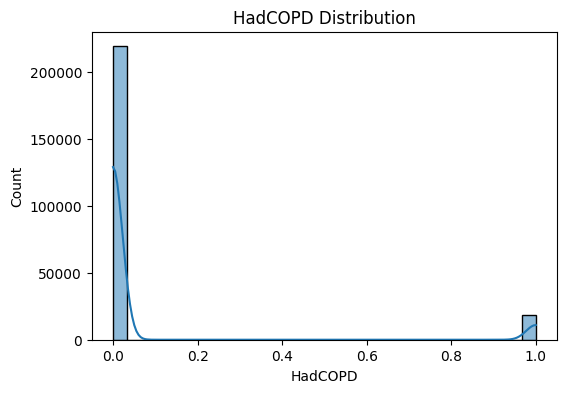

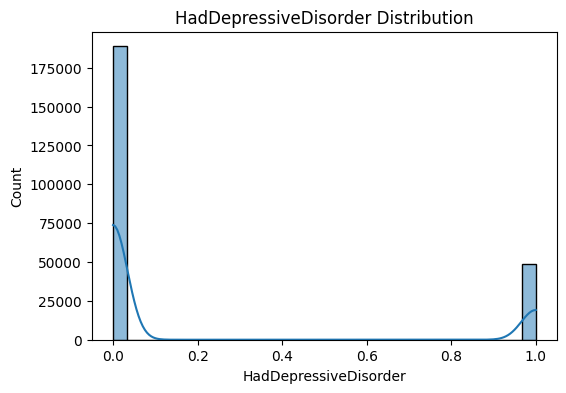

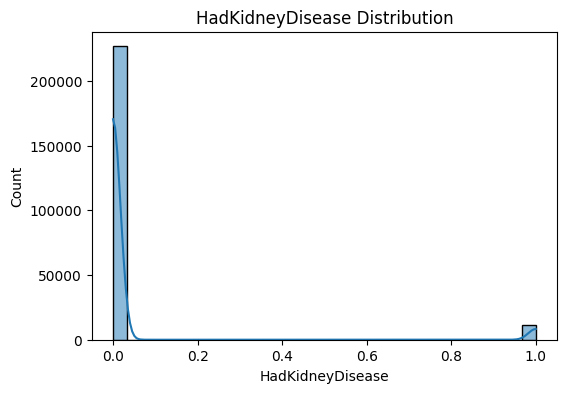

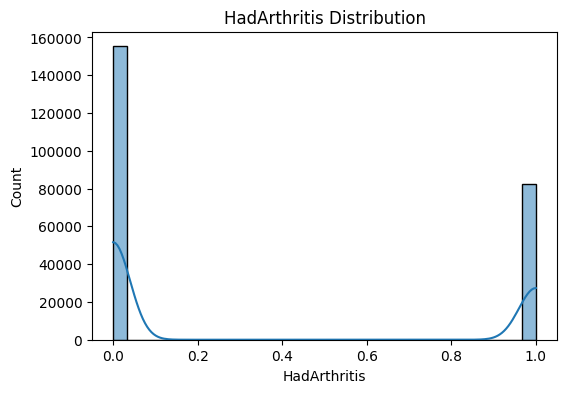

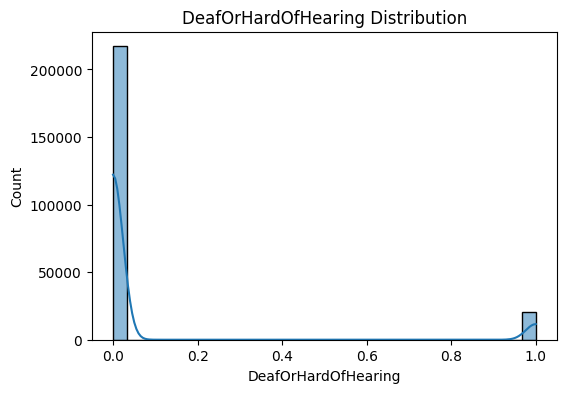

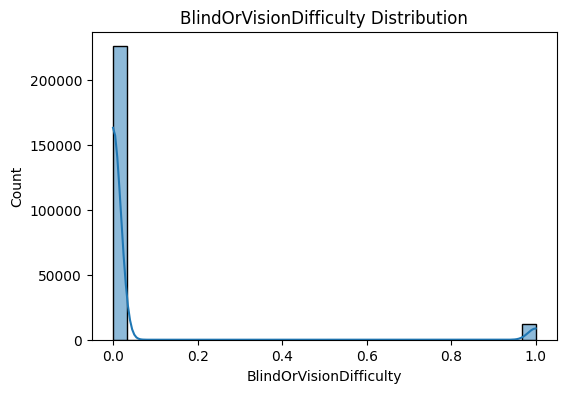

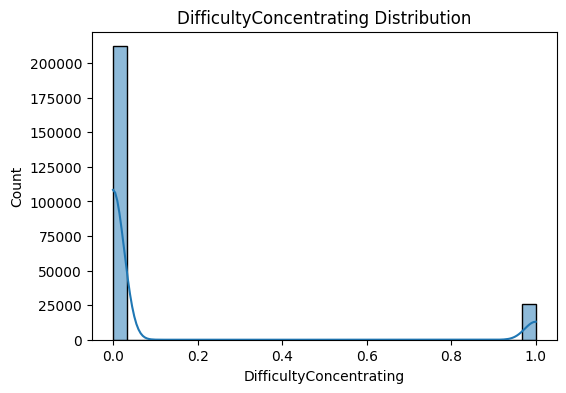

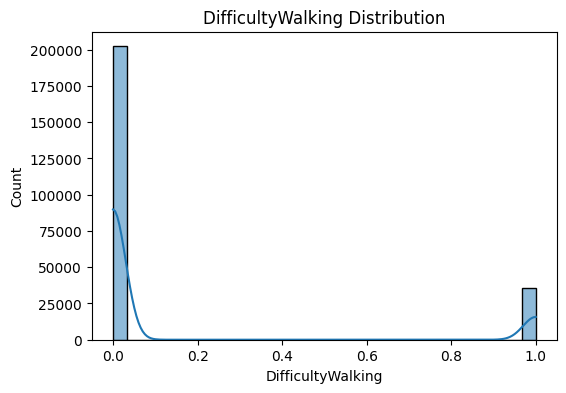

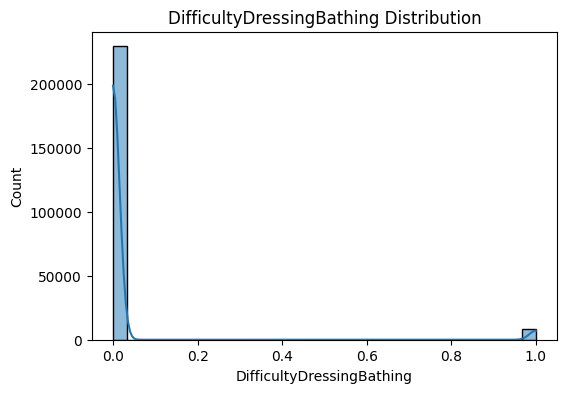

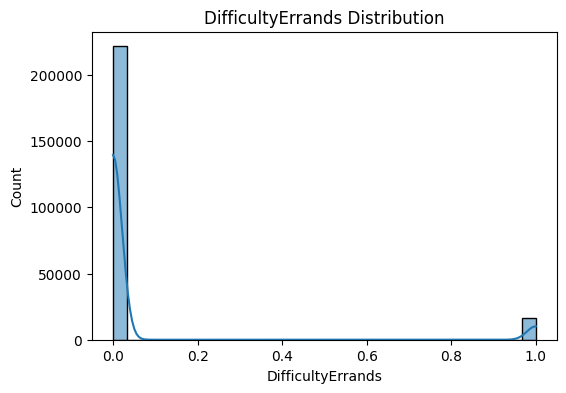

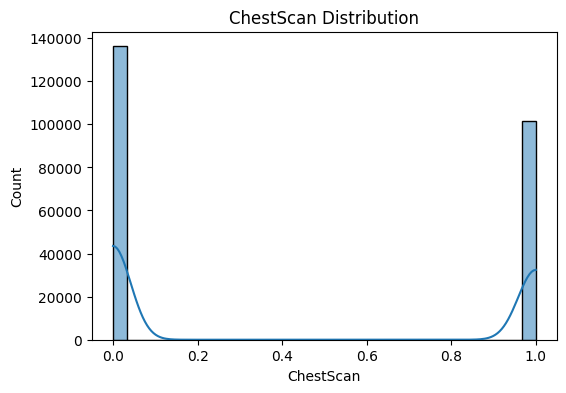

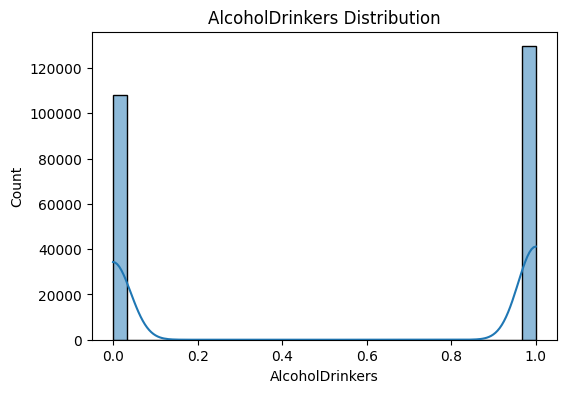

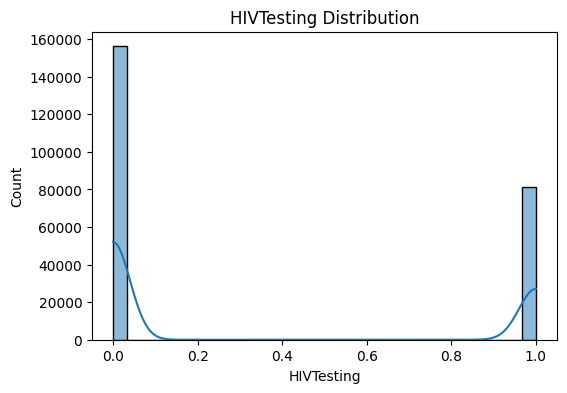

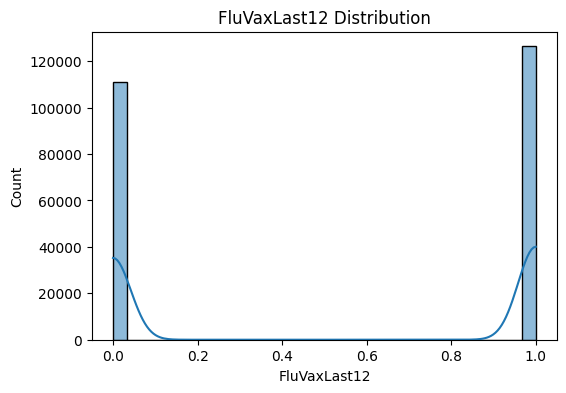

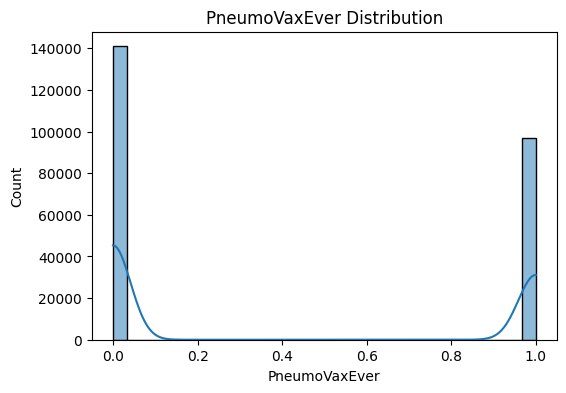

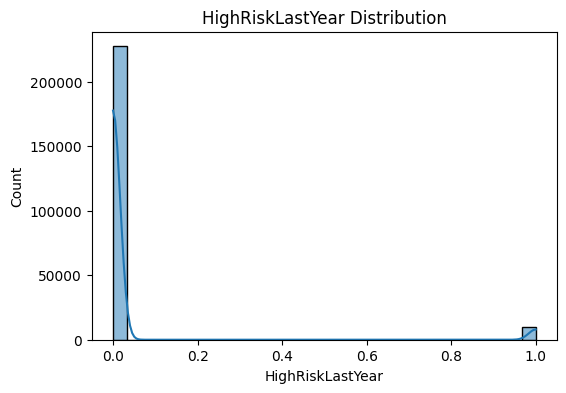

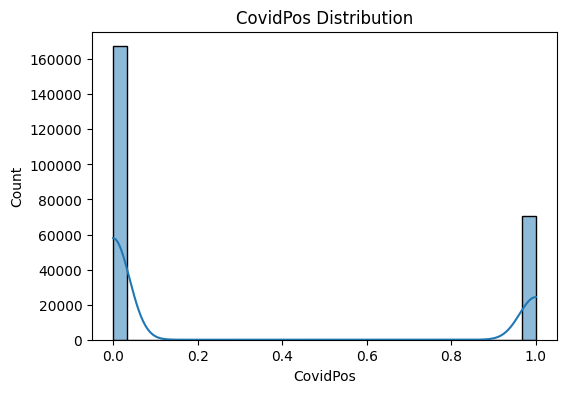

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


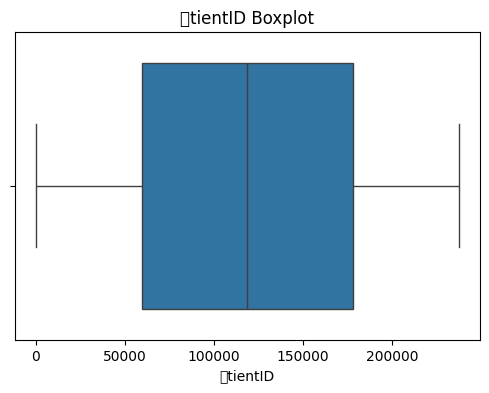

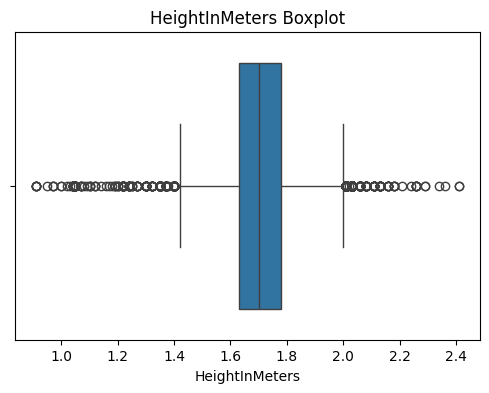

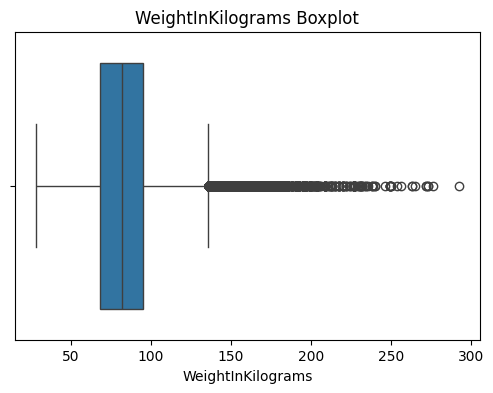

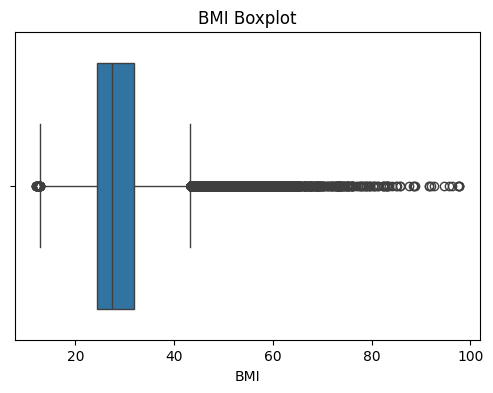

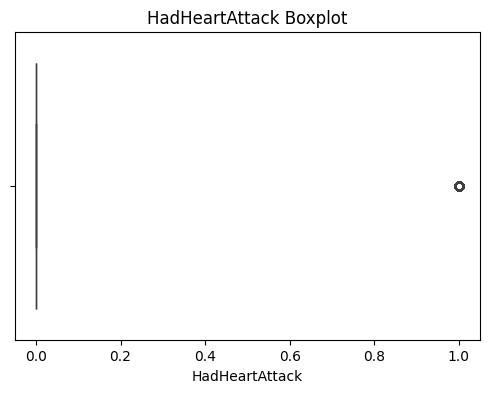

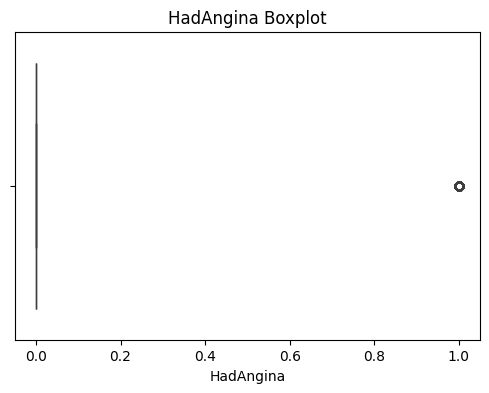

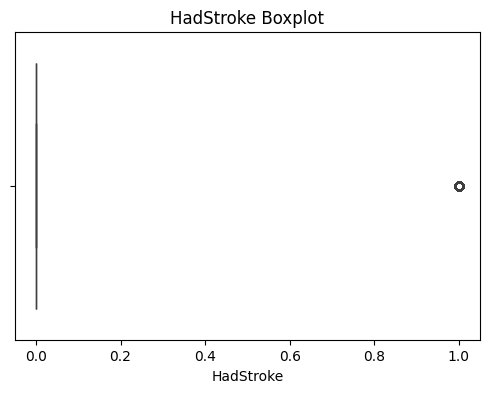

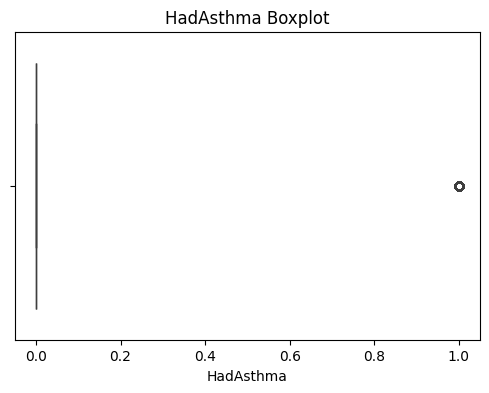

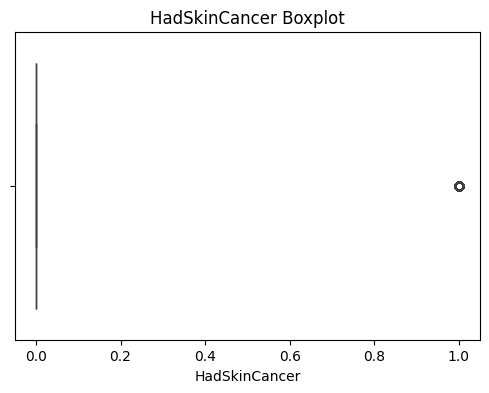

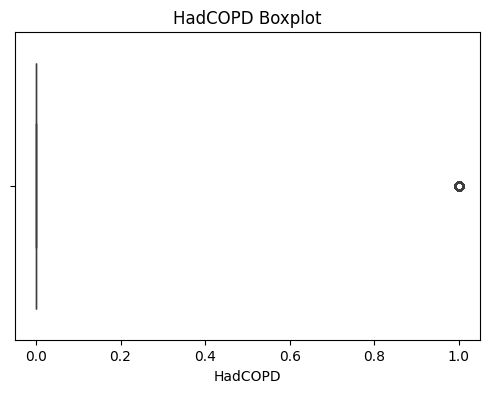

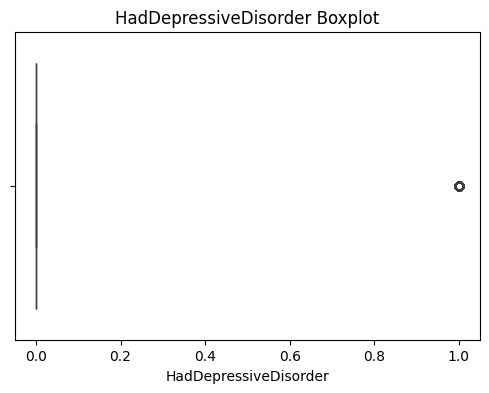

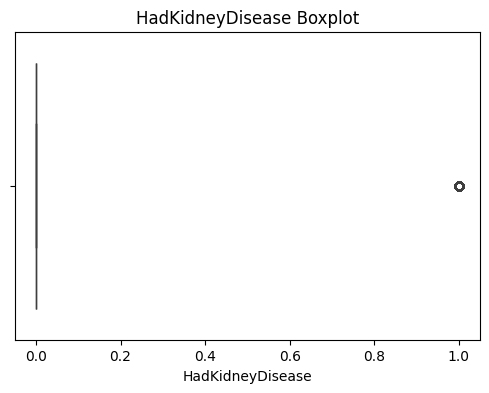

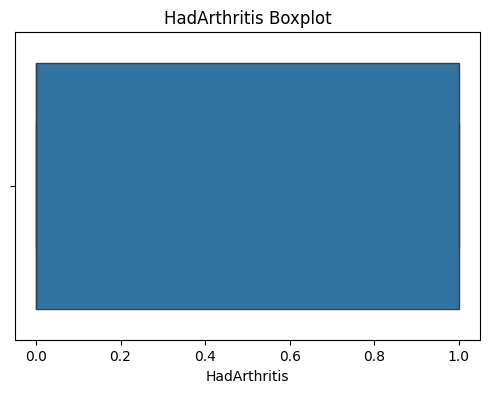

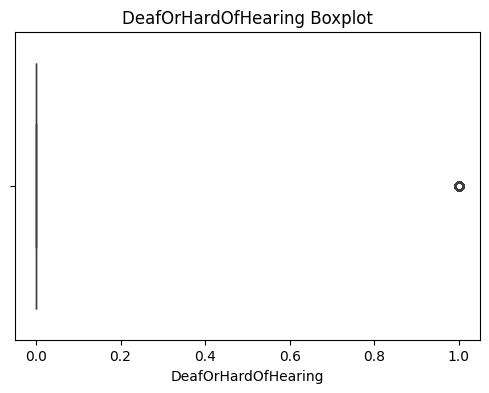

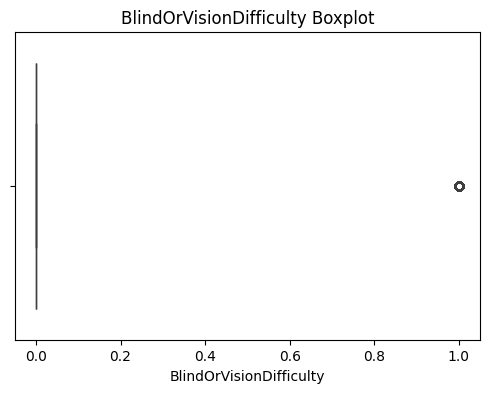

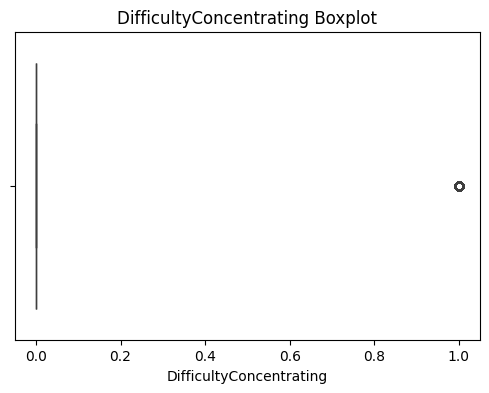

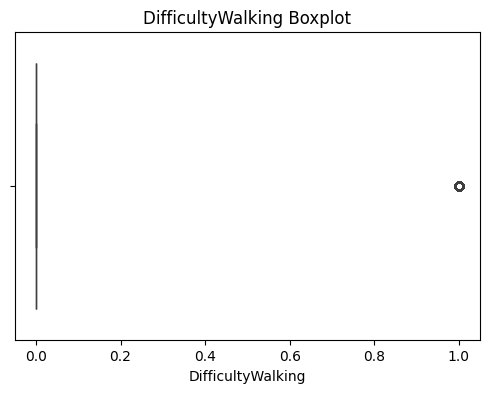

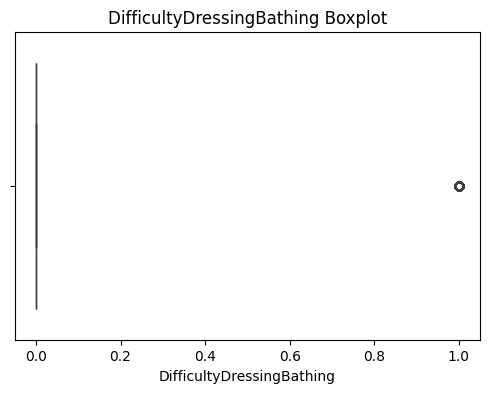

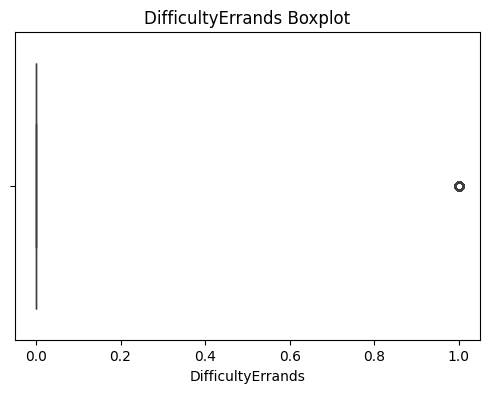

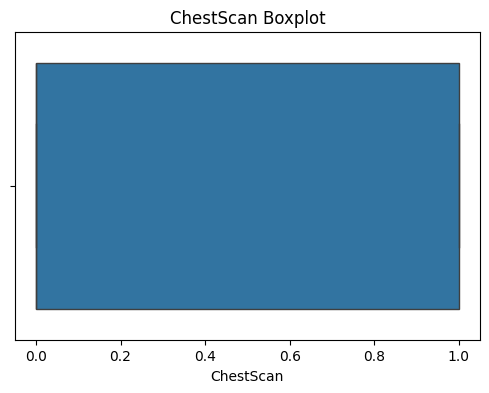

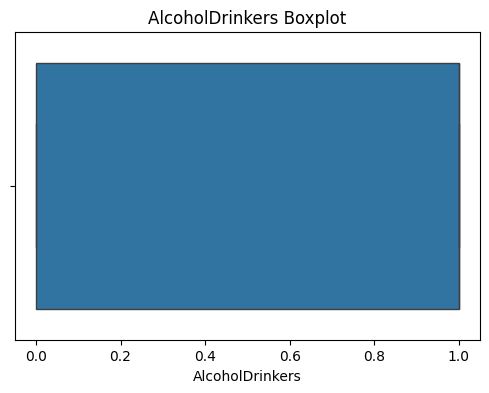

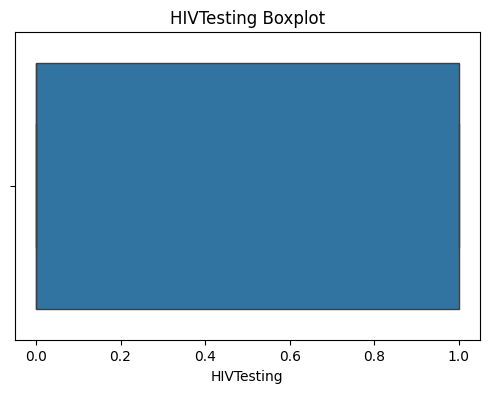

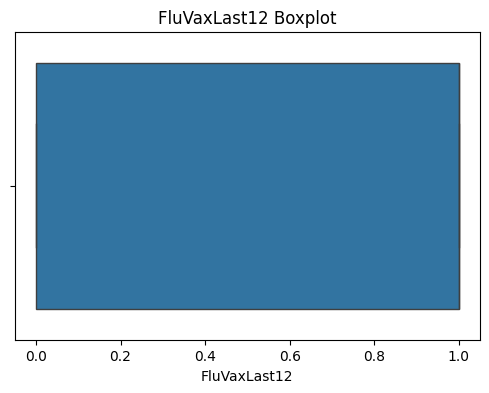

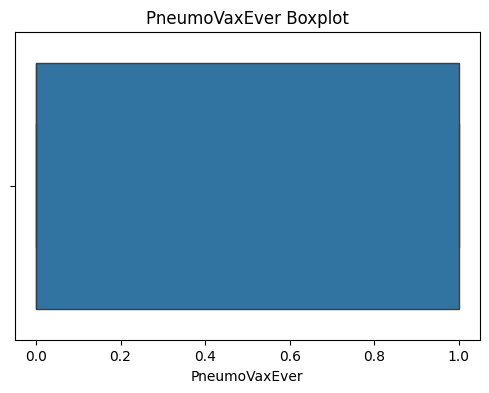

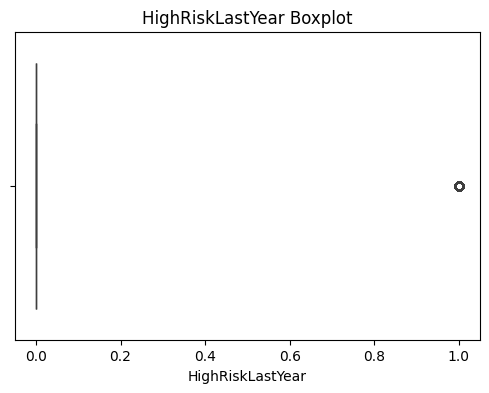

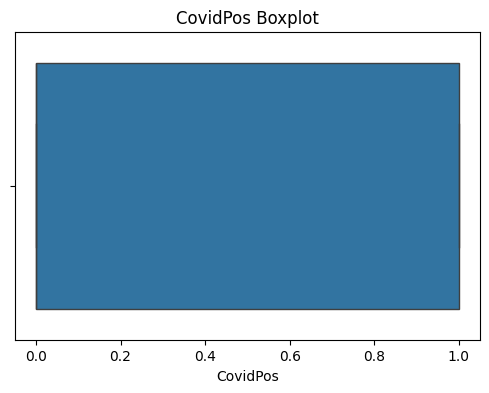

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# Features and Target
x = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['HadHeartAttack'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['HadHeartAttack'].value_counts())

   tientID  State  Sex  GeneralHealth  AgeCategory  HeightInMeters  \
0         1      0    0              1           11            1.63   
1         2      0    0              4            9            1.60   
2         3      0    1              0            8            1.78   
3         4      0    1              4           10            1.78   
4         5      0    0              2            6            1.68   

   WeightInKilograms        BMI  HadAngina  HadStroke  ...  ChestScan  \
0          84.820000  32.099998          1          0  ...          1   
1          71.669998  27.990000          0          0  ...          0   
2          71.209999  22.530001          0          0  ...          0   
3          95.250000  30.129999          0          0  ...          0   
4          78.019997  27.760000          0          0  ...          1   

   RaceEthnicityCategory  AlcoholDrinkers  HIVTesting  FluVaxLast12  \
0                      4                0           0          

In [ ]:
df=df_resampled

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


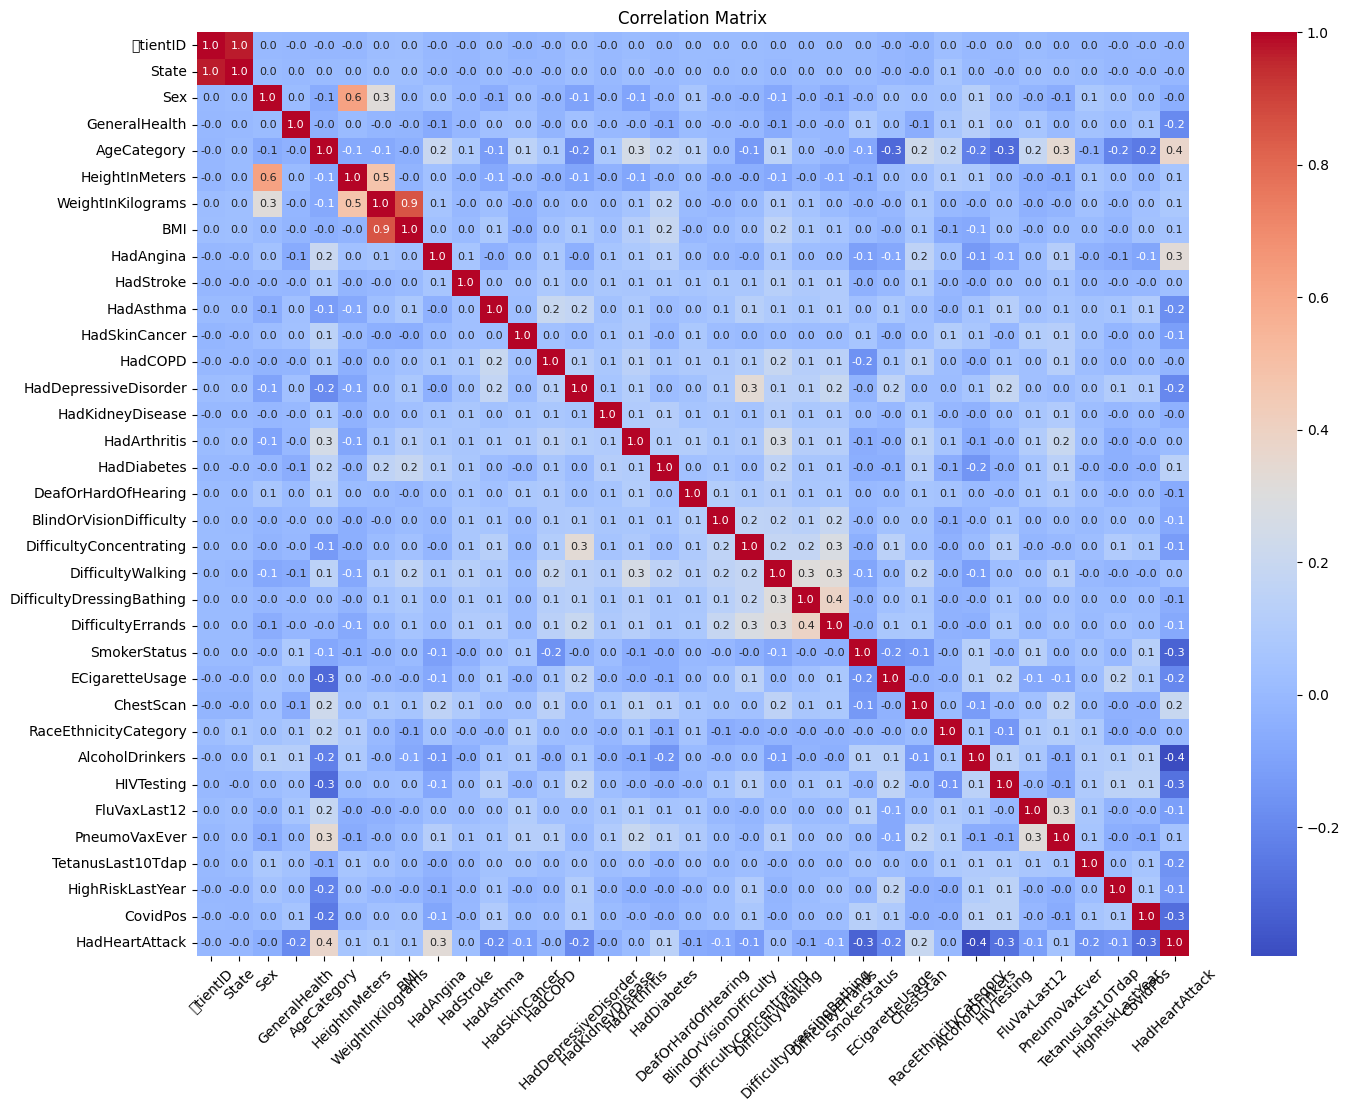

In [ ]:
plt.figure(figsize=(16,12))
cm=df.corr(numeric_only=True)
sns.heatmap(cm,annot=True,
            fmt=".1f",
            cmap="coolwarm",
            annot_kws={"size":8})

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
corr=df.corr(numeric_only=True)[target]
corr=corr.drop(target)
corr

,HadHeartAttack
tientID,-0.009742
State,-0.009723
Sex,-0.049580
GeneralHealth,-0.192653
AgeCategory,0.368804
HeightInMeters,0.058002
WeightInKilograms,0.074250
BMI,0.053819
HadAngina,0.326804
HadStroke,0.026913


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


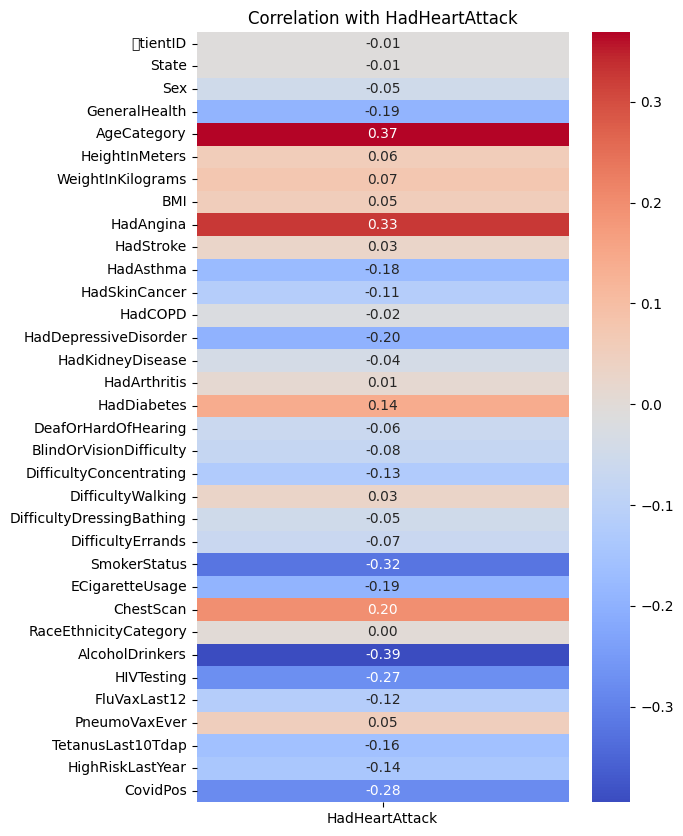

In [ ]:
plt.figure(figsize=(6,10))

sns.heatmap(corr.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True)

plt.title('Correlation with HadHeartAttack')
plt.show()

In [ ]:
top_corr=corr.sort_values(ascending=False)
top_corr

,HadHeartAttack
AgeCategory,0.368804
HadAngina,0.326804
ChestScan,0.196325
HadDiabetes,0.139400
WeightInKilograms,0.074250
HeightInMeters,0.058002
BMI,0.053819
PneumoVaxEver,0.051185
DifficultyWalking,0.030883
HadStroke,0.026913


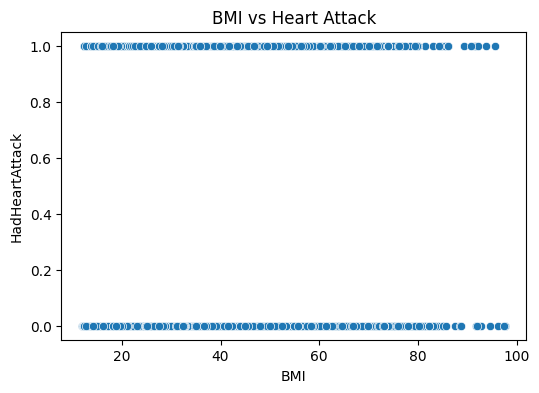

In [ ]:
if 'BMI' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='BMI',y=target,data=df)
    plt.title("BMI vs Heart Attack")
    plt.show()

In [ ]:
if 'SleepHours' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='SleepHours',y=target,data=df)
    plt.title("SleepHours vs Heart Attack")
    plt.show()

In [ ]:
if 'PhysicalHealthDays' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='PhysicalHealthDays',y=target,data=df)
    plt.title("PhysicalHealthDays vs Heart Attack")
    plt.show()

In [ ]:
if 'MentalHealthDays' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='MentalHealthDays',y=target,data=df)
    plt.title("MentalHealthDays vs Heart Attack")
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


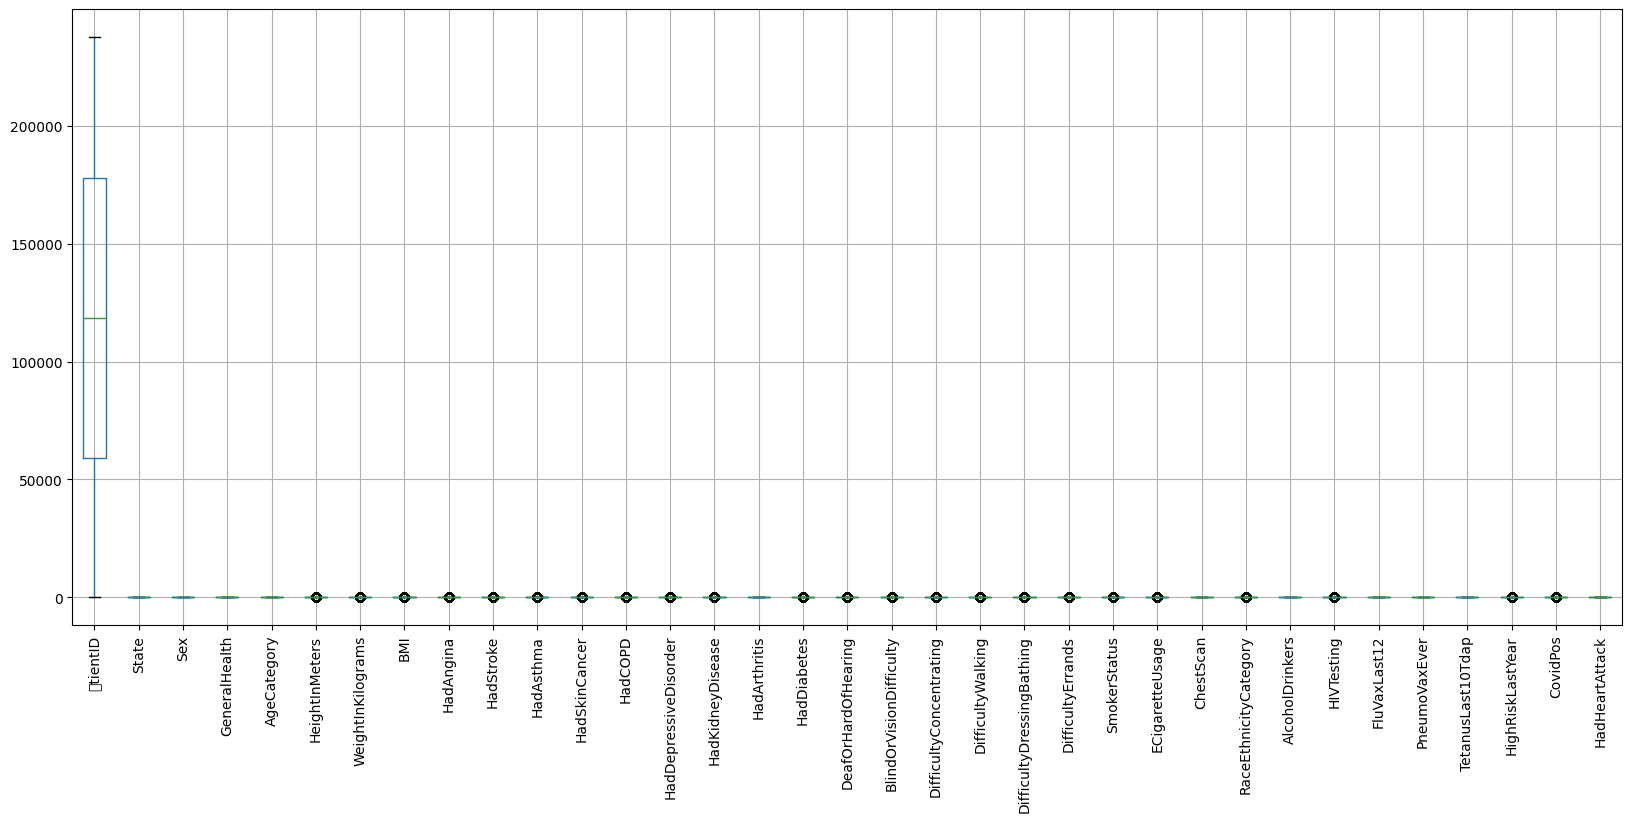

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(79105, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79105 entries, 1 to 448856
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   tientID                   79105 non-null  int64  
 1   State                      79105 non-null  int64  
 2   Sex                        79105 non-null  int64  
 3   GeneralHealth              79105 non-null  int64  
 4   AgeCategory                79105 non-null  int64  
 5   HeightInMeters             79105 non-null  float64
 6   WeightInKilograms          79105 non-null  float64
 7   BMI                        79105 non-null  float64
 8   HadAngina                  79105 non-null  int64  
 9   HadStroke                  79105 non-null  int64  
 10  HadAsthma                  79105 non-null  int64  
 11  HadSkinCancer              79105 non-null  int64  
 12  HadCOPD                    79105 non-null  int64  
 13  HadDepressiveDisorder      79105 non-null  int64  

In [ ]:
from sklearn.preprocessing import MinMaxScaler
features=df.drop(target,axis=1).columns
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)
scaled_df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadAngina,HadStroke,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,0.000000,0.000000,0.0,1.00,0.750000,0.306897,0.365359,0.488485,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.333333,0.0,0.0
1,0.000004,0.000000,1.0,0.00,0.666667,0.632788,0.360419,0.282211,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.666667,0.0,0.0
2,0.000034,0.000000,0.0,0.50,1.000000,0.216371,0.448161,0.680403,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.000000,0.0,0.0
3,0.000105,0.000000,1.0,1.00,1.000000,0.723314,0.910928,0.814519,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.333333,0.0,0.0
4,0.000126,0.000000,1.0,1.00,0.166667,0.759524,0.716112,0.577266,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.333333,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79100,0.691914,0.716981,0.0,0.50,0.666667,0.423470,0.345237,0.380620,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
79101,0.902303,0.943396,0.0,0.50,0.583333,0.478468,0.446121,0.470903,0.0,0.0,...,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.333333,0.0,0.0
79102,0.645613,0.679245,1.0,0.25,0.750000,0.730952,0.720226,0.589464,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0
79103,0.106973,0.113208,0.0,0.50,0.666667,0.518884,0.817182,0.891076,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pandas as pd

x=df.drop('HadHeartAttack',axis=1)

y=df['HadHeartAttack']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)

print(f'Baseline Model Accuracy Score: {accuracy:.2f}')

Baseline Model Accuracy Score: 0.83


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8320776659756283


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))


Classification Report
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      7697
           1       0.85      0.88      0.87     12080

    accuracy                           0.83     19777
   macro avg       0.83      0.82      0.82     19777
weighted avg       0.83      0.83      0.83     19777



In [ ]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))


Confusion Matrix
[[ 5768  1929]
 [ 1392 10688]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9299185923041917


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)


y_pred_rf = rf_model.predict(x_test)

print("Random Forest Accuracy:",accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9494362137836881


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9362896293674471


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada_model = AdaBoostClassifier(random_state=42)

ada_model.fit(x_train, y_train)

y_pred_ada = ada_model.predict(x_test)

print("AdaBoost Accuracy:",accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.8940183040906103


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42)

xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

print("XGBoost Accuracy:",accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9748192344642767


In [ ]:
from sklearn.metrics import confusion_matrix

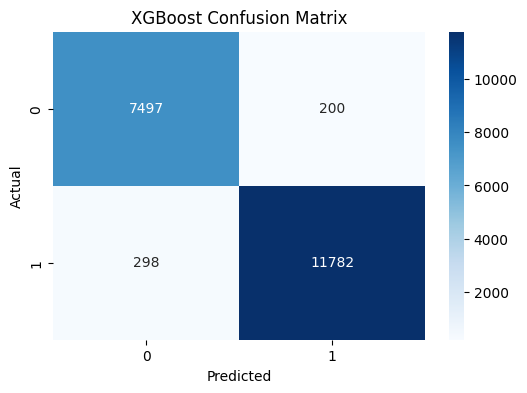

In [ ]:
cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(kernel='rbf')

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

print("SVM Accuracy:",accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.6108105374930475


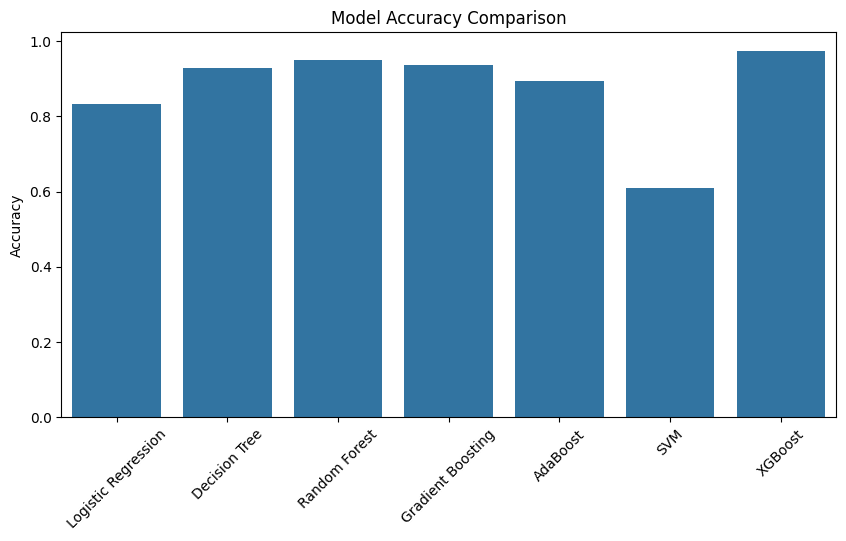

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred_lr),
    accuracy_score(y_test,y_pred_dt),
    accuracy_score(y_test,y_pred_rf),
    accuracy_score(y_test,y_pred_gb),
    accuracy_score(y_test,y_pred_ada),
    accuracy_score(y_test,y_pred_svm),
    accuracy_score(y_test,y_pred_xgb)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**K-Fold Cross Validation**

In [ ]:
X=df.drop('HadHeartAttack',axis=1)
y=df['HadHeartAttack']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(X),1):

    print(f"\nFold {fold}")

    X_train,X_test=X.iloc[train_index],X.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=X_train
        best_y_train=y_train

        best_X_test=X_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 0.8378105050249668

Fold 2
Accuracy: 0.8366727766892106

Fold 3
Accuracy: 0.8373680551166172

Fold 4
Accuracy: 0.8421717969786991

Fold 5
Accuracy: 0.8374312622463814

Best Fold: 4 with Accuracy: 0.8421717969786991


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 0.8421717969786991


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.9513937172113014


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.9274382150306555


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.6094431451867771


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.9348966563428355


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.8891979015232918


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9756652550407686


**Deep Learning Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


model=Sequential()
model.add(Dense(256,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(best_X_train,best_y_train,epochs=100)

y_pred=model.predict(best_X_test)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1978/1978 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8710 - loss: 0.3075
Epoch 2/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8914 - loss: 0.2614
Epoch 3/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8994 - loss: 0.2444
Epoch 4/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9028 - loss: 0.2374
Epoch 5/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9049 - loss: 0.2319
Epoch 6/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9086 - loss: 0.2255
Epoch 7/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9111 - loss: 0.2189
Epoch 8/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9142 - loss: 0.2128
Epoch 9/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9163 - loss: 0.2065
Epoch 10/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9203 - loss: 0.1997
Epoch 11/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9219 - loss: 0.1948
Epoch 12/100
1978/1978 ━━━━━━━━

# Conclusion

This project successfully developed a **Heart Attack Prediction System** using both **Machine Learning** and **Deep Learning** techniques to predict whether a patient has experienced a heart attack based on demographic, lifestyle, and health-related attributes. Since the target variable `HadHeartAttack` contains two possible outcomes (`0` and `1`), the problem was approached as a **Binary Classification** task under **Supervised Learning**. Comprehensive data preprocessing techniques, including **Label Encoding, SMOTE oversampling, feature scaling, outlier removal, and exploratory data analysis**, were applied to enhance data quality and improve model performance.

Several Machine Learning models, including **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, Support Vector Machine (SVM), and XGBoost**, were implemented and evaluated alongside a **Deep Learning model** developed using **TensorFlow** and **Keras**. In addition, **K-Fold Cross Validation** was applied to improve model reliability and ensure robust performance evaluation. Among all the models tested, the **XGBoost Classifier** achieved the highest accuracy of **97.57%**, demonstrating superior predictive capability and overall performance. The results of this project highlight the potential of Machine Learning and Deep Learning techniques in supporting healthcare professionals with early risk identification, preventive healthcare strategies, and improved clinical decision-making for heart disease prediction.